# Get plots for paper
This notebook creates the plots used in the research paper.

Change the current working directory to repo root.

In [ ]:
import os
os.chdir("../.")
os.getcwd()

In [ ]:
%cd scratch/acu

In [1]:
import pandas as pd
from scipy.stats import spearmanr
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import datasets

/scratch/users/ntu/clar0092/envs/persona/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set configuration values 

In [3]:
ZERO_SHOT_PROMPT = False # whether to load the data checkpoint for the zero-shot prompt setting or not
DATA_NAMES = ["CounterFact", "ConflictQA", "DRUID"]
MODEL_NAMES = ["Llama"]

## Load data checkpoint

A data checkpoint with all of the context properties and model predictions should previously have been created in src/prepare_data.ipynb. Load it from the directory below, or use the Hugging Face datasets [checkpoint](https://huggingface.co/datasets/copenlu/reality-check-on-context-utilisation).

For the Hugging Face checkpoint, we need to specify the feature types or the data generator will fail:

In [47]:
features = datasets.Features({
    'id': datasets.Value('string'), 
    'claim': datasets.Value('string'),
    'evidence': datasets.Value('string'),
    'evidence_stance': datasets.Value('string'),
    'relevant': datasets.Value('string'),
    'factcheck_verdict': datasets.Value('string'),
    'claim_id': datasets.Value('string'),
    'implicit_rate_ner': datasets.Value('float64'),
    'flesch_reading_ease_score': datasets.Value('float64'),
    'uncertain_discourse_markers': datasets.Value('string'),
    'uncertain_hedge_terms': datasets.Value('string'),
    'uncertain_boosters_preceeded_by_negation': datasets.Value('string'),
    'claim_evidence_jaccard_sim': datasets.Value('float64'),
    'claim_repeated_in_evidence': datasets.Value('bool'),
    'evidence_length': datasets.Value('int32'),
    'claim_length': datasets.Value('int32'),
    'ppl_Llama': datasets.Value('float64'),
    'ppl_Pythia': datasets.Value('float64'),
    'p_True_claim_prompt': datasets.Value('float64'),
    'p__True_claim_prompt': datasets.Value('float64'),
    'p_False_claim_prompt': datasets.Value('float64'),
    'p__False_claim_prompt': datasets.Value('float64'),
    'p_None_claim_prompt': datasets.Value('float64'),
    'p__None_claim_prompt': datasets.Value('float64'),
    'p_Support_claim_prompt': datasets.Value('float64'),
    'p__Support_claim_prompt': datasets.Value('float64'),
    'p_Refute_claim_prompt': datasets.Value('float64'),
    'p__Refute_claim_prompt': datasets.Value('float64'),
    'p_True_evidence_prompt': datasets.Value('float64'),
    'p__True_evidence_prompt': datasets.Value('float64'),
    'p_False_evidence_prompt': datasets.Value('float64'),
    'p__False_evidence_prompt': datasets.Value('float64'),
    'p_None_evidence_prompt': datasets.Value('float64'),
    'p__None_evidence_prompt': datasets.Value('float64'),
    'p_Support_evidence_prompt': datasets.Value('float64'),
    'p__Support_evidence_prompt': datasets.Value('float64'),
    'p_Refute_evidence_prompt': datasets.Value('float64'),
    'p__Refute_evidence_prompt': datasets.Value('float64'),
    'claim_source': datasets.Value('string'),
    'factcheck_verdict_num': datasets.Value('float64'),
    'prediction_wo_evidence_claim_prompt_stance': datasets.Value('string'),
    'prediction_wo_evidence_claim_prompt_stance_num': datasets.Value('float64'),
    'prediction_w_evidence_evidence_prompt_stance': datasets.Value('string'),
    'prediction_w_evidence_evidence_prompt_stance_num': datasets.Value('float64'),
    'p_True_wo_evidence': datasets.Value('float64'),
    'p_False_wo_evidence': datasets.Value('float64'),
    'p_None_wo_evidence': datasets.Value('float64'),
    'p_True_w_evidence': datasets.Value('float64'),
    'p_False_w_evidence': datasets.Value('float64'),
    'p_None_w_evidence': datasets.Value('float64'),
    'dataset': datasets.Value('string'),
    'model': datasets.Value('string'),
    'evidence_source': datasets.Value('string'),
    'refers_external_source_cohere': datasets.Value('string'),
    'claimant': datasets.Value('string'),
    'claim_date': datasets.Value('string'),
    'evidence_date': datasets.Value('string'),
    'evidence_published_after_claim': datasets.Value('string'),
    'is_gold': datasets.Value('string'),
    'text': datasets.Value('string'),
    'is_factcheck_article': datasets.Value('string'),
    'unreliable_mbfc': datasets.Value('string'),
    'evidence_contains_true': datasets.Value('bool'),
    'evidence_contains_false': datasets.Value('bool'),
    'claim_published_before_train': datasets.Value('string'),
    'targeted_jaccard_sim': datasets.Value('float64'),
    'diff_p_None_scaled': datasets.Value('float64'),
    'diff_p_True_scaled': datasets.Value('float64'),
    'diff_p_False_scaled': datasets.Value('float64'),
    'memory_conflict': datasets.Value('string'),
    'pred_aligned_w_evidence': datasets.Value('string'),
    'pred_aligned_wo_evidence': datasets.Value('string'),
    'pred_switched': datasets.Value('string'),
    'pred_switched_to_align': datasets.Value('string')
})

In [4]:
data = pd.read_csv("data/res/base/Olmo_all.csv")

/tmp/ipykernel_3015466/3462206814.py:1: DtypeWarning: Columns (5,10,38,53,54,55,56,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/res/base/Olmo_all.csv")


In [5]:
data.shape

(22669, 85)

In [ ]:
# def clean_data(df):
#     df = df.drop(columns=[c for c in df.columns if c.endswith(('evidence_prompt', 'claim_prompt', 'wo_evidence'))])
#     df = df.drop(columns=['prediction_wo_evidence_claim_prompt_stance',
#         'prediction_wo_evidence_claim_prompt_stance_num',
#         'prediction_w_evidence_evidence_prompt_stance',
#         'prediction_w_evidence_evidence_prompt_stance_num'])
#     print(df.shape)
#     return df

# data_cqa = clean_data(data_cqa)
# data_cf = clean_data(data_cf)

# # Validate that the columns are equal
# print(data_druid.columns.equals(data_cf.columns))
# print(data_cf.columns.equals(data_cqa.columns))
# data = pd.concat([data_druid, data_cqa, data_cf], ignore_index=True)

In [ ]:
# fix None data types and set index
data = data.replace({np.nan: None}).set_index("id")

Fix type of boolean columns (formatted as strings by HuggingFace datasets)

In [6]:
data["refers_external_source_cohere"] = data["refers_external_source_cohere"].map({"True": True, "False": False})
data["unreliable_mbfc"] = data["unreliable_mbfc"].map({"True": True, "False": False})
data["uncertain_hedge_terms"] = data["uncertain_hedge_terms"].map({"True": True, "False": False})
data["uncertain_discourse_markers"] = data["uncertain_discourse_markers"].map({"True": True, "False": False})
data["is_factcheck_article"] = data["is_factcheck_article"].map({"True": True, "False": False})
data["is_gold"] = data["is_gold"].map({"True": True, "False": False})
data["evidence_published_after_claim"] = data["evidence_published_after_claim"].map({"True": True, "False": False})
data["memory_conflict"] = data["memory_conflict"].map({"True": True, "False": False})

In [7]:
data = data.drop(columns=[c for c in data.columns if c.startswith(('diff'))])

In [ ]:
# mask = data['evidence_stance'].isin(['refutes', 'supports', 'insufficient-neutral'])
# data = data[mask]

In [8]:
data['evidence_stance'].value_counts()

evidence_stance
supports                 21818
refutes                   3520
insufficient-neutral      1996
insufficient-supports     1370
insufficient-refutes      1114
not_applicable             182
Name: count, dtype: int64

In [9]:
data['p_False_ins'] = data[['p_Refute', 'p__Refute', 'p_False', 'p__False']].max(axis=1)
data['p_True_ins'] = data[['p_Support', 'p__Support', 'p_True', 'p__True']].max(axis=1)
data['p_None_ins'] = data[['p_None', 'p__None']].max(axis=1)

In [10]:
data = data.drop(columns=['p_True', 'p__True',
       'p_False', 'p__False', 'p_None', 'p__None', 'p_Support', 'p__Support',
       'p_Refute', 'p__Refute', 'pred_aligned_w_evidence', 'pred_switched',
       'pred_switched_to_align', 'prediction_w_evidence'
       ])
data = data[data['model'] == 'Llama']

# Rename the non-instruct, original values
data = data.rename(columns={
    "p_None_w_evidence": "p_None_base",
    "p_False_w_evidence": "p_False_base",
    "p_True_w_evidence": "p_True_base",
})

Investigate the original dataset.

In [43]:
df = datasets.load_dataset("copenlu/reality-check-on-context-utilisation", "zero-shot", split="train", features=features)
df = pd.DataFrame(df)

In [ ]:
mask = df['evidence_stance'] == 'support'
subset = df[mask]

check = subset[['p_Support_evidence_prompt', 'p__Support_evidence_prompt',
                'p_True_evidence_prompt', 'p__True_evidence_prompt']].max(axis=1)

import numpy as np
np.allclose(check, subset['p_True_w_evidence'], equal_nan=True)

Back to work.

In [11]:
def get_scaled_p_diff(p_w, p_wo):
    if p_w is None:
        return None
    # scale by how much the model can move in p space
    if p_w < p_wo:
        return (p_w-p_wo)/p_wo
    else:
        return (p_w-p_wo)/(1-p_wo)
    # return p_w - p_wo
    
data["diff_p_None_scaled"] = data.apply(lambda row: get_scaled_p_diff(row["p_None_ins"], row["p_None_base"]), axis=1)
data["diff_p_True_scaled"] = data.apply(lambda row: get_scaled_p_diff(row["p_True_ins"], row["p_True_base"]), axis=1)
data["diff_p_False_scaled"] = data.apply(lambda row: get_scaled_p_diff(row["p_False_ins"], row["p_False_base"]), axis=1)

In [12]:
data['base_answer'] = data[['p_False_base', 'p_True_base', 'p_None_base']].idxmax(axis=1).map({
    'p_False_base': 'False',
    'p_True_base': 'True',
    'p_None_base': 'None'
})

In [13]:
DESIRED_CHANGES = {"False": {"diff_p_False_scaled": 1,
                               "diff_p_None_scaled": -1,
                               "diff_p_True_scaled": -1},
                   "True": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": -1,
                               "diff_p_True_scaled": 1},
                   "None": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": -1}}

def get_acu(row):
    if row.evidence_stance is None:
        return None
    agg_cu = 0
    for metric in ["diff_p_False_scaled", "diff_p_None_scaled", "diff_p_True_scaled"]:
        agg_cu += DESIRED_CHANGES[row.base_answer][metric]*row[metric] /3
    return agg_cu


data["cu"] = data.apply(get_acu, axis=1)

In [14]:
display(data[['p_True_ins', 'p_True_base', 'diff_p_True_scaled', 'p_None_ins', 'p_None_base', 'diff_p_None_scaled', 'p_False_ins', 'p_False_base', 'diff_p_False_scaled', 'base_answer', 'cu']])

,p_True_ins,p_True_base,diff_p_True_scaled,p_None_ins,p_None_base,diff_p_None_scaled,p_False_ins,p_False_base,diff_p_False_scaled,base_answer,cu
id,,,,,,,,,,,
srilankafactcrescendo_98_ret_bn_g11_Llama,0.019777,0.151621,-0.869563,0.102779,0.182787,-0.437711,0.593165,0.44735,0.263847,False,0.523707
srilankafactcrescendo_85_ret_bn_g9_Llama,0.401643,0.160048,0.287629,0.000510,0.108783,-0.995310,0.275319,0.545172,-0.494987,False,0.070898
srilankafactcrescendo_85_ret_bn_g5_Llama,0.395878,0.215469,0.229958,0.107072,0.180315,-0.406196,0.208751,0.432166,-0.516966,False,-0.113576
srilankafactcrescendo_85_ret_bn_g0_Llama,0.812479,0.249875,0.750014,0.000392,0.120952,-0.996759,0.034180,0.424413,-0.919465,False,-0.224240
srilankafactcrescendo_85_ret_b0_g7_Llama,0.935878,0.109719,0.927976,0.000003,0.117464,-0.999974,0.007589,0.581055,-0.986939,False,-0.304980
...,...,...,...,...,...,...,...,...,...,...,...
counterfact_5504_sup_Llama,0.010868,0.194373,-0.944087,0.145680,0.263549,-0.447236,0.740800,0.288809,0.635541,False,0.675621
counterfact_5503_sup_Llama,0.230246,0.349811,-0.341798,0.197491,0.204778,-0.035584,0.242530,0.145192,0.113871,True,-0.140028
counterfact_5502_sup_Llama,0.672243,0.355436,0.491506,0.042755,0.227379,-0.811964,0.028920,0.144331,-0.799629,True,0.701033


In [15]:
data.columns[data.isna().all()]

Index(['uncertain_discourse_markers', 'uncertain_hedge_terms',
       'refers_external_source_cohere', 'evidence_published_after_claim',
       'is_gold', 'is_factcheck_article', 'unreliable_mbfc',
       'memory_conflict'],
      dtype='object')

Since the above columns are somehow gone, we should get it from the checkpoint.

In [16]:
# Drop first
data = data.drop(columns=['uncertain_discourse_markers', 'uncertain_hedge_terms',
       'refers_external_source_cohere', 'evidence_published_after_claim',
       'is_gold', 'is_factcheck_article', 'unreliable_mbfc',
       'memory_conflict'])

In [19]:
df = datasets.load_dataset("copenlu/reality-check-on-context-utilisation", "zero-shot", split="train", features=features)
df = pd.DataFrame(df)

In [20]:
missing_cols = ['uncertain_discourse_markers', 'uncertain_hedge_terms',
                'refers_external_source_cohere', 'evidence_published_after_claim',
                'is_gold', 'is_factcheck_article', 'unreliable_mbfc',
                'memory_conflict']

df = df.replace({np.nan: None}).set_index("id")
data[missing_cols] = df[missing_cols].reindex(data.index)

In [21]:
data.columns

Index(['claim', 'evidence', 'evidence_stance', 'relevant', 'factcheck_verdict',
       'claim_id', 'implicit_rate_ner', 'flesch_reading_ease_score',
       'uncertain_boosters_preceeded_by_negation',
       'claim_evidence_jaccard_sim', 'claim_repeated_in_evidence',
       'evidence_length', 'claim_length', 'ppl_Llama', 'ppl_Pythia',
       'claim_source', 'factcheck_verdict_num', 'p_True_base', 'p_False_base',
       'p_None_base', 'dataset', 'model', 'evidence_source', 'claimant',
       'claim_date', 'evidence_date', 'text', 'evidence_contains_true',
       'evidence_contains_false', 'claim_published_before_train',
       'targeted_jaccard_sim', 'p_False_ins', 'p_True_ins', 'p_None_ins',
       'diff_p_None_scaled', 'diff_p_True_scaled', 'diff_p_False_scaled',
       'base_answer', 'cu', 'uncertain_discourse_markers',
       'uncertain_hedge_terms', 'refers_external_source_cohere',
       'evidence_published_after_claim', 'is_gold', 'is_factcheck_article',
       'unreliable_mbfc', 

In [22]:
data["refers_external_source_cohere"] = data["refers_external_source_cohere"].map({"True": True, "False": False})
data["unreliable_mbfc"] = data["unreliable_mbfc"].map({"True": True, "False": False})
data["uncertain_hedge_terms"] = data["uncertain_hedge_terms"].map({"True": True, "False": False})
data["uncertain_discourse_markers"] = data["uncertain_discourse_markers"].map({"True": True, "False": False})
data["is_factcheck_article"] = data["is_factcheck_article"].map({"True": True, "False": False})
data["is_gold"] = data["is_gold"].map({"True": True, "False": False})
data["evidence_published_after_claim"] = data["evidence_published_after_claim"].map({"True": True, "False": False})
data["memory_conflict"] = data["memory_conflict"].map({"True": True, "False": False})

In [23]:
data.to_csv("data/res/Llama_0_shot.csv")

# **Work from below**

In [24]:
data = pd.read_csv("data/res/Llama_0_shot.csv")

In [25]:
feature_cols = ['claim_evidence_jaccard_sim',
                'targeted_jaccard_sim',
                'claim_repeated_in_evidence',
                'flesch_reading_ease_score',
                'claim_length',
                'evidence_length',
                'ppl_Llama',
                'implicit_rate_ner',
                'refers_external_source_cohere',
                'unreliable_mbfc',
                'uncertain_hedge_terms',
                'uncertain_discourse_markers',
                'evidence_contains_true',
                'evidence_contains_false',
                'is_factcheck_article', 
                'is_gold',
                'evidence_published_after_claim', 
                'factcheck_verdict_num'
                ]

feature_col_names = {'is_factcheck_article': 'Fact-check source', 
                     'evidence_published_after_claim': 'Pub. after claim', 
                     'is_gold': 'Gold source', 
                     'unreliable_mbfc': 'Unreliable source',
                     'factcheck_verdict_num': 'Fact-check verdict',
                     'implicit_rate_ner': 'Claim entity overlap', 
                     'claim_evidence_jaccard_sim': 'Jaccard similarity', 
                     'claim_repeated_in_evidence': 'Repeats claim', 
                     'evidence_contains_true': 'Contains "True"', 
                     'evidence_contains_false': 'Contains "False"',
                     'flesch_reading_ease_score': 'Flesch reading ease score', 
                     'ppl_Llama': 'Llama: Perplexity', 
                     'uncertain_discourse_markers': 'Contains hedging disc.', 
                     'uncertain_hedge_terms': 'Contains hedging',
                     'refers_external_source_cohere': 'Detection by LLM', 
                     'uncertain_cohere': 'Uncertain (Cohere)', 
                     'unreliable_cohere': 'Unreliable (Cohere)', 
                     'implicit_cohere': 'Implicit (Cohere)',
                     'evidence_length': 'Evidence length', 
                     'claim_length': 'Claim length',
                     'targeted_jaccard_sim': 'Claim-evidence overlap'}

# switch implicit_rate_ner to "claim entity overlap"
data["implicit_rate_ner"] = 1-data["implicit_rate_ner"]

# only include cols found in the dataset
feature_cols = [col for col in feature_cols if col in data.columns]

for c in feature_cols:
    print(c, data[c].dtype)

claim_evidence_jaccard_sim float64
targeted_jaccard_sim float64
claim_repeated_in_evidence bool
flesch_reading_ease_score float64
claim_length int64
evidence_length int64
ppl_Llama float64
implicit_rate_ner float64
refers_external_source_cohere object
unreliable_mbfc object
uncertain_hedge_terms bool
uncertain_discourse_markers bool
evidence_contains_true bool
evidence_contains_false bool
is_factcheck_article object
is_gold object
evidence_published_after_claim object
factcheck_verdict_num float64


/tmp/ipykernel_1860128/2965956868.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = spearmanr(subset['cu'], subset[f].astype(float), nan_policy='omit')
/tmp/ipykernel_1860128/2965956868.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = spearmanr(subset['cu'], subset[f].astype(float), nan_policy='omit')
/tmp/ipykernel_1860128/2965956868.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = spearmanr(subset['cu'], subset[f].astype(float), nan_policy='omit')
/tmp/ipykernel_1860128/2965956868.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = spearmanr(subset['cu'], subset[f].astype(float), nan_policy='omit')
/tmp/ipykernel_1860128/2965956868.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = spearmanr(sub

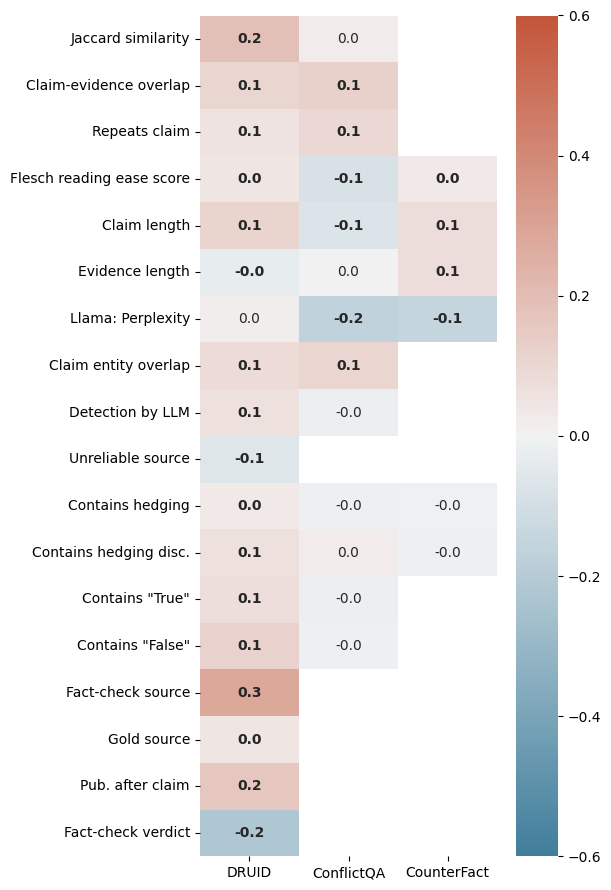

In [26]:
from scipy.stats import spearmanr

sets = data['dataset'].unique()
corr_dict = {}
sig_dict = {}

for d in sets:
    subset = data[data.dataset == d]
    corrs = {}
    sigs = {}
    for f in feature_cols:
        res = spearmanr(subset['cu'], subset[f].astype(float), nan_policy='omit')
        corrs[f] = res.statistic
        sigs[f] = res.pvalue
    corr_dict[d] = corrs
    sig_dict[d] = sigs

corr_df = pd.DataFrame(corr_dict).rename(index=feature_col_names)
sig_df = pd.DataFrame(sig_dict).rename(index=feature_col_names)

cmap = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(6, 9))

mask_ns = sig_df >= 0.05
mask_sig = sig_df < 0.05

ax = sns.heatmap(data=corr_df, annot=True, fmt=".1f",
                 cmap=cmap, vmax=.6, vmin=-.6, center=0,
                 mask=~mask_ns, annot_kws={"fontstyle": "normal"})
sns.heatmap(data=corr_df, annot=True, fmt=".1f",
            cmap=cmap, vmax=.6, vmin=-.6, center=0,
            mask=~mask_sig, annot_kws={"fontweight": "heavy"},
            ax=ax, cbar=False)
plt.tight_layout()
plt.show()

In [28]:
for d in data['dataset'].unique():
    subset = data[data.dataset == d]
    for f in feature_cols:
        if subset[f].nunique(dropna=True) <= 1:
            print(f"Constant: {f} in {d} (value: {subset[f].dropna().unique()})")

Constant: unreliable_mbfc in ConflictQA (value: [False])
Constant: is_factcheck_article in ConflictQA (value: [])
Constant: is_gold in ConflictQA (value: [])
Constant: evidence_published_after_claim in ConflictQA (value: [])
Constant: factcheck_verdict_num in ConflictQA (value: [])
Constant: claim_evidence_jaccard_sim in CounterFact (value: [1.])
Constant: targeted_jaccard_sim in CounterFact (value: [1.])
Constant: claim_repeated_in_evidence in CounterFact (value: [ True])
Constant: implicit_rate_ner in CounterFact (value: [1.])
Constant: refers_external_source_cohere in CounterFact (value: [])
Constant: unreliable_mbfc in CounterFact (value: [False])
Constant: evidence_contains_true in CounterFact (value: [False])
Constant: evidence_contains_false in CounterFact (value: [False])
Constant: is_factcheck_article in CounterFact (value: [])
Constant: is_gold in CounterFact (value: [])
Constant: evidence_published_after_claim in CounterFact (value: [])
Constant: factcheck_verdict_num in Cou

/scratch/users/ntu/clar0092/envs/persona/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tmp/ipykernel_1860128/2148943668.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = mannwhitneyu(x[y == 1], x[y == 0], alternative='two-sided')
/scratch/users/ntu/clar0092/envs/persona/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tmp/ipykernel_1860128/2148943668.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = mannwhitneyu(x[y == 1], x[y == 0], alternative='two-sided')
/scratch/users/ntu/clar0092/envs/persona/lib

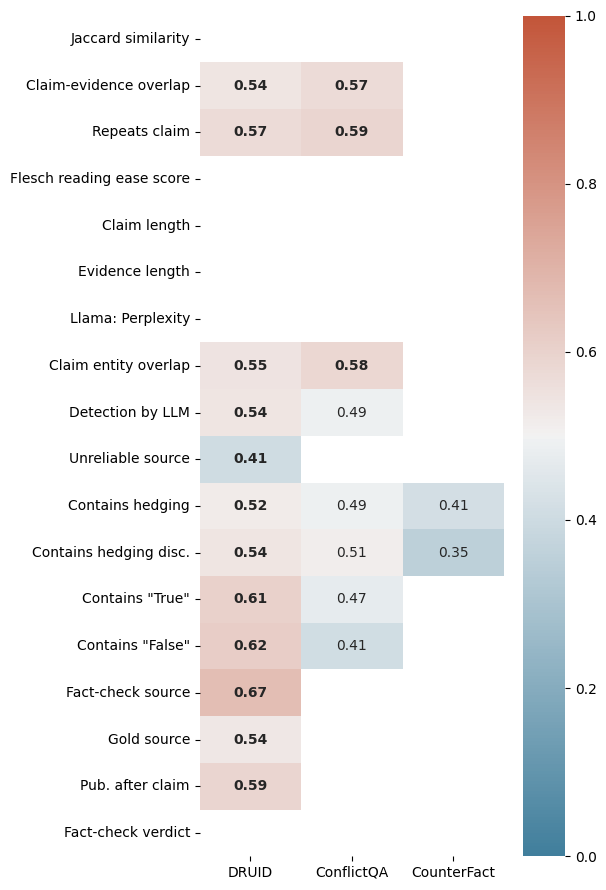

In [29]:
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

sets = data['dataset'].unique()
auc_dict = {}
sig_dict = {}

for d in sets:
    subset = data[data.dataset == d]
    aucs = {}
    sigs = {}
    for f in feature_cols:
        mask = subset['cu'].notna() & subset[f].notna()
        y = subset.loc[mask, f].astype(int).values
        x = subset.loc[mask, 'cu'].astype(float).values
        try:
            aucs[f] = roc_auc_score(y, x)
            _, p = mannwhitneyu(x[y == 1], x[y == 0], alternative='two-sided')
            sigs[f] = p
        except ValueError:
            aucs[f] = float('nan')
            sigs[f] = float('nan')
    auc_dict[d] = aucs
    sig_dict[d] = sigs

auc_df = pd.DataFrame(auc_dict).rename(index=feature_col_names)
sig_df = pd.DataFrame(sig_dict).rename(index=feature_col_names)

cmap = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(6, 9))

mask_ns = sig_df >= 0.05
mask_sig = sig_df < 0.05

ax = sns.heatmap(data=auc_df, annot=True, fmt=".2f",
                 cmap=cmap, vmax=1.0, vmin=0.0, center=0.5,
                 mask=~mask_ns, annot_kws={"fontstyle": "normal"})
sns.heatmap(data=auc_df, annot=True, fmt=".2f",
            cmap=cmap, vmax=1.0, vmin=0.0, center=0.5,
            mask=~mask_sig, annot_kws={"fontweight": "heavy"},
            ax=ax, cbar=False)
plt.tight_layout()
plt.show()

In [32]:
data["cu"].describe()

count    15000.000000
mean         0.378786
std          0.484469
min         -0.601392
25%         -0.096297
50%          0.470493
75%          0.853437
max          0.992753
Name: cu, dtype: float64

In [43]:
df.shape

(169126, 73)

In [44]:
df['dataset'].value_counts()

dataset
DRUID          97034
CounterFact    40000
ConflictQA     32092
Name: count, dtype: int64

In [57]:
data['cu'].describe()

count    5000.000000
mean        0.377858
std         0.387442
min        -0.401632
25%         0.069513
50%         0.389936
75%         0.731501
max         0.992753
Name: cu, dtype: float64

## Get characteristics plot

Fix DRUID/DRUID+ notation

In [ ]:
DRUID_data = data[(data.dataset=="DRUID") & ~(data.evidence_stance.isna())].copy()
DRUID_data = DRUID_data.set_index(pd.Index([f"{ix}_DRUID" for ix in DRUID_data.index]))
data["dataset"] = data.dataset.replace({"DRUID": "DRUID+"})
data = pd.concat((data, DRUID_data))

Set context property (refers to external source) for CounterFact, for which we know that there never are references to external sources.

In [ ]:
counterfact_ix = data[data.dataset=="CounterFact"].index
data.loc[counterfact_ix, "refers_external_source_cohere"] = False

Make the plot

In [ ]:
num_y_plots = 6
plot_cols = {(0,0): 'claim_evidence_jaccard_sim',
             (0,1): 'targeted_jaccard_sim',
             (1,0): 'claim_repeated_in_evidence',
             (2,0): 'claim_length',
             (2,1): 'evidence_length',
             (3,0): 'ppl_Llama',
             (3,1): 'flesch_reading_ease_score',
             (4,0): 'implicit_rate_ner',
             (4,1): 'unreliable_mbfc',
             (5,0): 'uncertain_hedge_terms',
             (5,1): 'uncertain_discourse_markers',
             (1,1): 'refers_external_source_cohere',
             }

percentage_cols = ['claim_repeated_in_evidence',
                   'refers_external_source_cohere',
                   'unreliable_mbfc',
                   'uncertain_hedge_terms',
                   'uncertain_discourse_markers']
perc_estimator = lambda x: sum(x)/len(x)*100

plot_titles = {(0,0): "Claim-evidence similarity",
               (2,0): "Difficult to understand",
               (4,0): "Implicit",
               (4,1): "Unreliable",
               (1,1): "Refers external source",
               (5,0): "Uncertain",
               }

hue_order = ["CounterFact", "DRUID", "DRUID+", "ConflictQA"]
colors_dict = {"CounterFact": '#EF8633', 
          "ConflictQA": '#559E3F', 
          "DRUID+": '#C6B3D4', 
          "DRUID": '#644095'}
colors = [colors_dict[v] for v in hue_order]
markers_dict = {"CounterFact": (4,0,45),
           "ConflictQA": (4,2,45), 
           "DRUID+": (4,1,0), 
           "DRUID": (8,1,0)}
markers = [markers_dict[v] for v in hue_order]

space_per_col = 0.42
# space_per_col = 1
f, axes = plt.subplots(num_y_plots, 2, figsize=(4,space_per_col*len(plot_cols)))
for ixs, col in plot_cols.items():
    # legend_setting = 'auto' if ixs==(0,1) else False
    legend_setting = False
    axes[ixs[0]][ixs[1]].hlines(y=0, xmin=-10, xmax=1000, color='black', linewidth=0.75)
    if col not in percentage_cols:
        sns.pointplot(data=data, x=col, hue="dataset", hue_order=hue_order, dodge=0, markersize=10, errorbar=None, palette=colors, markers=markers, ax=axes[ixs[0]][ixs[1]], legend=legend_setting, linestyle='')
        axes[ixs[0]][ixs[1]].set_xlabel(feature_col_names[col], labelpad=0, fontsize=9)
    else:
        sns.pointplot(data=data, estimator=perc_estimator, x=col, hue="dataset", hue_order=hue_order, dodge=0, markersize=10, errorbar=None, palette=colors, markers=markers, ax=axes[ixs[0]][ixs[1]], legend=legend_setting, linestyle='')
        axes[ixs[0]][ixs[1]].set_xlabel(feature_col_names[col]+" (%)", labelpad=0, fontsize=9)
        
    axes[ixs[0]][ixs[1]].set_yticks([])
    axes[ixs[0]][ixs[1]].set_ylim([-0.2,0.2])
    axes[ixs[0]][ixs[1]].spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    if ixs in plot_titles:
        axes[ixs[0]][ixs[1]].set_title(plot_titles[ixs], loc='left', fontweight="bold", fontsize=10, y=0.85)
    # move legend outside
    if legend_setting=='auto':
        axes[ixs[0]][ixs[1]].legend(title="Dataset")
        # sns.move_legend(axes[ix], "upper left", bbox_to_anchor=(1, 1))
        sns.move_legend(axes[ixs[0]][ixs[1]], "lower center", bbox_to_anchor=(-0.2, 1), ncol=2, title=None, frameon=False)

f.tight_layout()
plt.subplots_adjust(hspace=2.5)
plt.savefig(f"figures/characteristics/all.pdf", bbox_inches='tight')
plt.show()

## Get aggregated model probabilities

In [ ]:
agg_data = data.groupby(["dataset", "model"])[['p_False_wo_evidence', 'p_None_wo_evidence', 'p_True_wo_evidence']].agg(["mean", "std"])
agg_data

## Get context utilisation plot

Define the ACU metric (denoted "cu" for the dataframe)

In [ ]:
DESIRED_CHANGES = {"refutes": {"diff_p_False_scaled": 1,
                               "diff_p_None_scaled": -1,
                               "diff_p_True_scaled": -1},
                   "supports": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": -1,
                               "diff_p_True_scaled": 1},
                   "insufficient-neutral": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": -1},
                   "insufficient-contradictory": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": -1},
                   "insufficient-refutes": {"diff_p_False_scaled": 1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": -1},
                   "insufficient-supports": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": 1},
                   "not_applicable": {"diff_p_False_scaled": -1,
                               "diff_p_None_scaled": 1,
                               "diff_p_True_scaled": -1}}

def get_agg_context_usage(row):
    if row.evidence_stance is None:
        return None
    agg_cu = 0
    for metric in ["diff_p_False_scaled", "diff_p_None_scaled", "diff_p_True_scaled"]:
        agg_cu += DESIRED_CHANGES[row.evidence_stance][metric]*row[metric]/3
    return agg_cu

Plot ACU across all samples for sufficient evidence

In [ ]:
data["cu"] = data.apply(get_agg_context_usage, axis=1)
data["x"] = data.apply(lambda row: row.dataset+" "+row.evidence_stance if row.evidence_stance else row.dataset+" None", axis=1)
x_order = ['CounterFact refutes',
           'CounterFact supports',
           'ConflictQA refutes',
           'ConflictQA supports',
           'DRUID refutes',
           'DRUID supports']
ylim = [-0.4,0.95]

plt.figure(figsize=(4.5,4.5))
ax = sns.barplot(data=data[data.model.isin(MODEL_NAMES)], x="x", y="cu", hue="model", hue_order=MODEL_NAMES, errorbar="sd",
                 order=x_order)
xlim = ax.get_xlim()
ax.hlines(0, -1, 6, color="red", zorder=0)
[ax.axvline(x, color = 'grey', linestyle='--', linewidth=0.7) for x in [1.5,3.5]]

# add averaged ACU scores per dataset and model
dataset_xlims = {"CounterFact": [-0.5, 1.5], 
                 "ConflictQA": [1.5, 3.5], 
                 "DRUID": [3.5, 5.5]}
for dataset, xlims in dataset_xlims.items():
    for model in MODEL_NAMES:
        ax.hlines(data[(data.dataset==dataset) & \
                        (data.model==model) & \
                        (data.evidence_stance.isin(["supports", "refutes"]))].cu.mean(),
                   xlims[0],
                   xlims[1],
                   linestyle='--',
                   color="tab:blue" if model=="Llama" else "tab:orange")
        
ax.set_xlim(xlim)
ax.set_ylim(ylim)

locs, labels = plt.xticks()
plt.xticks(locs, ["refutes", "supports", "refutes", "supports", "refutes", "supports"], fontsize=9, rotation=0)
sec = ax.secondary_xaxis(location=0)
sec.set_xticks([0.5, 2.5, 4.5], labels=[f'\n\nCounterFact', f'\n\nConflictQA', f'\n\nDRUID'])
sec.tick_params('x', length=0)
sec.spines[['bottom']].set_visible(False)
plt.xlabel("")
plt.ylabel("ACU")

if ZERO_SHOT_PROMPT:
    plt.savefig(f"figures/context_usage/aggregated_zero_shot.pdf", bbox_inches='tight')
else:
    plt.savefig(f"figures/context_usage/aggregated.pdf", bbox_inches='tight')
plt.show()

**Zero-shot cu mean**

```python
model   dataset    
Llama   ConflictQA     0.564304
        CounterFact    0.572482
        DRUID          0.343839
Pythia  ConflictQA     0.498018
        CounterFact    0.322505
        DRUID          0.149094
```

**Few-shot cu mean**

In [ ]:
data.groupby(["model", "dataset"]).cu.mean()

Plot ACU across all samples for insufficient evidence

In [ ]:
x_order = ['insufficient-refutes',
           'insufficient-contradictory',
           'insufficient-neutral',
           'insufficient-supports']

plt.figure(figsize=(4.5,5))
ax = sns.barplot(data=data[data.evidence_stance.isin(x_order) & data.model.isin(MODEL_NAMES)], x="evidence_stance", y="cu", hue="model", hue_order=MODEL_NAMES, errorbar="sd",
                 order=x_order)

xlim = ax.get_xlim()
ax.hlines(0, -1, 6, color="red", zorder=0)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.xticks(rotation=10)
plt.ylabel("ACU")
plt.xlabel("")

if ZERO_SHOT_PROMPT:
    plt.savefig(f"figures/context_usage/aggregated_insuff_zero_shot.pdf", bbox_inches='tight')
else:
    plt.savefig(f"figures/context_usage/aggregated_insuff.pdf", bbox_inches='tight')
plt.show()

## Plot correlations tables

### To scaled p diff

In [ ]:
stances = ['refutes', 'supports']
col = "cu"
for model_name in MODEL_NAMES:
    print(f"Model: {model_name}")
    corr_data = {}
    significance_data = {}
    for d_name in DATA_NAMES:
        for stance in stances:
            if stance is not None and len(data[data.evidence_stance==stance]) > 0:
                tmp_data = data[(data.evidence_stance==stance) & (data.dataset==d_name) & (data.model==model_name)][[col] + feature_cols]

                # Compute the correlations
                col_name = stance+"\n"+d_name
                corr_data[col_name] = tmp_data.corr()[col].to_dict()
                # Compute the p values
                significance_entry = {}
                for other_col in corr_data[col_name].keys():
                    res = spearmanr(tmp_data[col], tmp_data[other_col].astype("float"), nan_policy='omit')
                    significance_entry[other_col] = res.pvalue
                significance_data[col_name] = significance_entry

    corr_data = pd.DataFrame(corr_data).T
    corr_data = corr_data.drop(columns=col).dropna(axis=1, how='all')
    corr_data = corr_data.rename(columns=feature_col_names)
    significance_data = pd.DataFrame(significance_data).T
    significance_data = significance_data.drop(columns=col).dropna(axis=1, how='all')
    significance_data = significance_data.rename(columns=feature_col_names)
    
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    plt.figure(figsize=(5,9))
    ax = sns.heatmap(data=corr_data.T[significance_data.T>=0.05], annot_kws={"fontstyle":"normal"}, cmap=cmap, vmax=.6, vmin=-.6, center=0, annot=True, fmt=".1f")
    sns.heatmap(data=corr_data.T[significance_data.T<0.05], annot_kws={"fontweight":"heavy"}, cmap=cmap, vmax=.6, vmin=-.6, center=0, annot=True, fmt=".1f", ax=ax, cbar=False)
    locs, labels = plt.xticks()
    plt.xticks(locs, [stances[0], stances[1], stances[0], stances[1], stances[0], stances[1]], fontsize=9, rotation=0)
    sec = ax.secondary_xaxis(location=0)
    sec.set_xticks([1, 3, 5], labels=[f'\n\n{DATA_NAMES[0]}', f'\n\n{DATA_NAMES[1]}', f'\n\n{DATA_NAMES[2]}'])
    sec.tick_params('x', length=0)
    sec.spines[['bottom']].set_visible(False)
    
    locs, labels = plt.yticks()
    sec_y = ax.secondary_yaxis(location=0)
    sec_y.set_yticks([0, 3, 8, 9, 10, 11, 13], labels=["Claim-evidence similarity", "Difficult to understand", "Implicit", "Refers external source", "Unreliable", "Uncertain", "Additional properties"], weight="bold")
    sec_y.tick_params('y', length=0, grid_color="white")
    sec_y.spines[['left']].set_visible(False)
    if ZERO_SHOT_PROMPT:
        plt.savefig(f"figures/correlations/p_{col}_{model_name}_zero_shot.pdf", bbox_inches='tight')
    else:
        plt.savefig(f"figures/correlations/p_{col}_{model_name}.pdf", bbox_inches='tight')
    plt.show()

For insufficient evidence from DRUID.

In [ ]:
stances = ['insufficient-refutes', 'insufficient-contradictory', 'insufficient-neutral', 'insufficient-supports']
col = "cu"
d_name = "DRUID"
for model_name in MODEL_NAMES:
    print(f"Model: {model_name}")
    corr_data = {}
    significance_data = {}
    for stance in stances:
        if stance is not None and len(data[data.evidence_stance==stance]) > 0:
            tmp_data = data[(data.evidence_stance==stance) & (data.dataset==d_name) & (data.model==model_name)][[col] + feature_cols]

            # Compute the correlations
            col_name = stance
            corr_data[col_name] = tmp_data.corr()[col].to_dict()
            # Compute the p values
            significance_entry = {}
            for other_col in corr_data[col_name].keys():
                res = spearmanr(tmp_data[col], tmp_data[other_col].astype("float"), nan_policy='omit')
                significance_entry[other_col] = res.pvalue
            significance_data[col_name] = significance_entry

    corr_data = pd.DataFrame(corr_data).T
    corr_data = corr_data.drop(columns=col).dropna(axis=1, how='all')
    corr_data = corr_data.rename(columns=feature_col_names)
    significance_data = pd.DataFrame(significance_data).T
    significance_data = significance_data.drop(columns=col).dropna(axis=1, how='all')
    significance_data = significance_data.rename(columns=feature_col_names)
    
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    plt.figure(figsize=(5,9))
    ax = sns.heatmap(data=corr_data.T[significance_data.T>=0.05], annot_kws={"fontstyle":"normal"}, cmap=cmap, vmax=.6, vmin=-.6, center=0, annot=True, fmt=".1f")
    sns.heatmap(data=corr_data.T[significance_data.T<0.05], annot_kws={"fontweight":"heavy"}, cmap=cmap, vmax=.6, vmin=-.6, center=0, annot=True, fmt=".1f", ax=ax, cbar=False)
    plt.xticks(rotation=15)
    
    locs, labels = plt.yticks()
    sec_y = ax.secondary_yaxis(location=0)
    sec_y.set_yticks([0, 3, 8, 9, 10, 11, 13], labels=["Claim-evidence similarity", "Difficult to understand", "Implicit", "Refers external source", "Unreliable", "Uncertain", "Additional properties"], weight="bold")
    sec_y.tick_params('y', length=0, grid_color="white")
    sec_y.spines[['left']].set_visible(False)
    if ZERO_SHOT_PROMPT:
        plt.savefig(f"figures/correlations/p_{col}_{model_name}_insuff_zero_shot.pdf", bbox_inches='tight')
    else:
        plt.savefig(f"figures/correlations/p_{col}_{model_name}_insuff.pdf", bbox_inches='tight')
    plt.show()

## Examples

- For each dataset, model, stance and cu case (2 examples)
- High context usage: cu>1.5
- Low context usage: 0 < cu < 0.5
- Anti-context usage: cu < -0.5

In [ ]:
def print_sample(sample_ix, data):
    s = data.loc[sample_ix]
    tab_sample = {"\\textbf{Dataset}": s.dataset,
                  "\\textbf{Claim}": s.claim,
                  "\\textbf{Evidence}": s.evidence,
                  "\\textbf{Evidence stance}": s.evidence_stance}
    def get_probs(s):
        tab_sample[f"$\\bm{{\\mathrm{{ACU}}_{{\\mathrm{{{s.model}}}}}}}$"] = f"{s.cu:.2f}"
        for t in ["False", "None", "True"]:
            p_val = s[f"p_{t}_wo_evidence"]
            tab_sample[f"$P_{{\\mathrm{{{s.model}}}}}(\mathrm{{{t}}}|C)$"] = f"{p_val:.2f}"
            p_val = s[f"p_{t}_w_evidence"]
            tab_sample[f"$P_{{\\mathrm{{{s.model}}}}}(\mathrm{{{t}}}|C, E)$"] = f"{p_val:.2f}"
    get_probs(s)
        
    # add other model preds for same samples
    if s.model == "Pythia":
        other_model = "Llama"
    else:
        other_model = "Pythia"
        
    other_model_ix = ix.replace(s.model, other_model)
    s = data.loc[other_model_ix]
    get_probs(s)
    print(pd.Series(tab_sample).to_latex())
    print()

n_samples = 1
for d_set in ["CounterFact", "ConflictQA", "DRUID"]:
    for model in ["Llama", "Pythia"]:
        for stance in ["refutes", "insufficient-neutral", "supports"]:
            tmp_data = data[(data.dataset==d_set) & (data.model==model) & (data.evidence_stance==stance)]
            if len(tmp_data) > 0:
                lb_cu = 1
                print("--------------------------")
                print(f"{lb_cu} < cu")
                try:
                    samples_ix = tmp_data[(tmp_data.cu>lb_cu)].sample(n_samples, random_state=41).index.tolist()
                    for ix in samples_ix:
                        print_sample(ix, data)
                except ValueError as e:
                    print(f"Error when printing sample for {model}, {d_set} and {stance}")
                    print(e)
                    
                print("--------------------------")
                lb_cu = 0
                ub_cu = 0.5
                print(f"{lb_cu} < cu < {ub_cu}")
                try:
                    samples_ix = tmp_data[(tmp_data.cu>lb_cu) & (tmp_data.cu<ub_cu)].sample(n_samples, random_state=42).index.tolist()
                    for ix in samples_ix:
                        print_sample(ix, data)
                except ValueError as e:
                    print(f"Error when printing sample for {model}, {d_set} and {stance}")
                    print(e)
                    
                print("--------------------------")
                ub_cu = -0.5
                print(f"cu < {ub_cu}")
                try:
                    samples_ix = tmp_data[(tmp_data.cu<ub_cu)].sample(n_samples, random_state=43).index.tolist()
                    for ix in samples_ix:
                        print_sample(ix, data)
                except ValueError as e:
                    print(f"Error when printing sample for {model}, {d_set} and {stance}")
                    print(e)